# Peringkas Berita Bahasa Indonesia dengan Transformer

## Pendahuluan

Proyek ini bertujuan untuk membangun model peringkasan teks (Text Summarization) menggunakan arsitektur **Transformer**. Ini adalah model ketiga dalam seri perbandingan kami, setelah sebelumnya mengimplementasikan `SimpleRNN` dan `LSTM`. Tujuannya adalah untuk menguji dan membandingkan performa arsitektur berbasis *attention* murni, seperti yang diperkenalkan di paper "Attention Is All You Need", dengan model berbasis *recurrent* dalam menangani data sekuens panjang untuk peringkasan berita Bahasa Indonesia.

URL Dataset : https://github.com/kata-ai/indosum

## Setup & Impor Library

Pada bagian ini, kami mengimpor semua library yang akan dibutuhkan untuk keseluruhan proyek, mulai dari pemrosesan data hingga pembangunan dan evaluasi model.

In [55]:
# Library dasar untuk manipulasi data dan komputasi
import os
import pandas as pd
import numpy as np
import re
import json

# Library untuk visualisasi
import matplotlib.pyplot as plt
from IPython.display import display

# Library TensorFlow dan Keras untuk pra-pemrosesan dan model
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Layer,
    MultiHeadAttention, LayerNormalization, Dropout, Add
)
from tensorflow.keras.models import Model

print("Semua library berhasil diimpor.")
print("Versi TensorFlow:", tf.__version__)

Semua library berhasil diimpor.
Versi TensorFlow: 2.19.0


## Persiapan Dataset (IndoSum)

Pada bagian ini, kami akan menyiapkan dataset IndoSum. Proses ini mencakup pengunduhan, pemuatan file data training, hingga pra-pemrosesan agar data siap digunakan untuk melatih model.

### Mengunduh dan Mengekstrak Dataset

Kami akan mengunduh file `indosum.tar.gz` dari Google Drive menggunakan gdown, kemudian mengekstraknya di lingkungan Colab menggunakan perintah tar.

In [56]:
# Mengunduh dataset indosum.tar.gz dari Google Drive
!gdown --id 1OgYbPfXFAv3TbwP1Qcwt_CC9cVWSJaco

# Mengekstrak file .tar.gz
!tar -xzvf indosum.tar.gz

print("\nDataset IndoSum berhasil diunduh dan diekstrak.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1OgYbPfXFAv3TbwP1Qcwt_CC9cVWSJaco
From (redirected): https://drive.google.com/uc?id=1OgYbPfXFAv3TbwP1Qcwt_CC9cVWSJaco&confirm=t&uuid=b40ddc9c-f9ef-4408-9fc0-06e1a1354308
To: /content/indosum.tar.gz
100% 96.0M/96.0M [00:02<00:00, 36.4MB/s]
indosum/
indosum/test.02.jsonl
indosum/README.txt
indosum/train.05.jsonl
indosum/train.04.jsonl
indosum/test.04.jsonl
indosum/train.01.jsonl
indosum/test.05.jsonl
indosum/test.03.jsonl
indosum/test.01.jsonl
indosum/dev.04.jsonl
indosum/dev.01.jsonl
indosum/dev.02.jsonl
indosum/train.02.jsonl
indosum/dev.03.jsonl
indosum/dev.05.jsonl
indosum/CHANGELOG.txt
indosum/train.03.jsonl

Dataset IndoSum berhasil diunduh dan diekstrak.


### Pemuatan Data

Setelah dataset berhasil diunduh dan diekstrak, sekarang kami akan memuat salah satu file data, yaitu train.01.jsonl, ke dalam tabel (DataFrame Pandas).

In [57]:
# --- Pemuatan Data (Gabungkan SEMUA Folds) ---
import pandas as pd

# Buat daftar nama file
train_files = [f'indosum/train.0{i}.jsonl' for i in range(1, 6)]
dev_files = [f'indosum/dev.0{i}.jsonl' for i in range(1, 6)]

# Muat dan gabungkan semua file training
df_train_list = []
for f in train_files:
    df_train_list.append(pd.read_json(f, lines=True))
df_train = pd.concat(df_train_list, ignore_index=True)

# Muat dan gabungkan semua file validasi
df_val_list = []
for f in dev_files:
    df_val_list.append(pd.read_json(f, lines=True))
df_val = pd.concat(df_val_list, ignore_index=True)

print(f"Total data TRAINING (gabungan): {len(df_train)}")
print(f"Total data VALIDASI (gabungan): {len(df_val)}")

# Tampilkan contoh
print("\nContoh 5 Baris Pertama Data Training (Gabungan):")
display(df_train[['paragraphs', 'summary']].head())

Total data TRAINING (gabungan): 71353
Total data VALIDASI (gabungan): 3743

Contoh 5 Baris Pertama Data Training (Gabungan):


,paragraphs,summary
0,"[[[Jakarta, ,, CNN, Indonesia, -, -, Dokter, R...","[[Dokter, Lula, Kamal, yang, merupakan, selebr..."
1,"[[[Selfie, ialah, salah, satu, tema, terpanas,...","[[Asus, memperkenalkan, , ZenFone, generasi, ..."
2,"[[[Jakarta, ,, CNN, Indonesia, -, -, Dinas, Pa...","[[Dinas, Pariwisata, Provinsi, Bengkulu, kemba..."
3,"[[[Merdeka.com, -, Indonesia, Corruption, Watc...","[[Indonesia, Corruption, Watch, (, ICW, ), mem..."
4,"[[[Merdeka.com, -, Presiden, Joko, Widodo, (, ...","[[Jokowi, memimpin, upacara, penurunan, bender..."


### Pra-pemrosesan Teks

Pada tahap ini, kami akan membersihkan teks di kolom paragraphs dan summary. Kami menggunakan fungsi `clean_text` yang dirancang untuk menangani struktur data kompleks dari dataset IndoSum (termasuk list bersarang) dengan mengubahnya menjadi satu string tunggal. Setelah itu, kami akan menambahkan token `<start>` dan `<end>` pada setiap kalimat ringkasan yang sudah bersih untuk mempersiapkannya sebagai input bagi decoder.

In [58]:
# Fungsi clean_text
def clean_text(data):
    text = str(data).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r"[\"\[\],']", '', text)
    text = re.sub(r'[^a-z0-9\s.\-]', '', text)
    text = re.sub(r'(?<!\d)\-|-(?!\d)', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\s\.', '.', text)
    text = text.replace(u'xa0', u'')
    return text

# Menerapkan fungsi cleaning ke df_train
print("Membersihkan data training...")
df_train['artikel_bersih'] = df_train['paragraphs'].apply(clean_text)
df_train['ringkasan_bersih'] = df_train['summary'].apply(clean_text)
df_train['ringkasan_decoder'] = df_train['ringkasan_bersih'].apply(lambda x: '<start> ' + x + ' <end>')

# Menerapkan fungsi cleaning ke df_val
print("Membersihkan data validasi...")
df_val['artikel_bersih'] = df_val['paragraphs'].apply(clean_text)
df_val['ringkasan_bersih'] = df_val['summary'].apply(clean_text)
df_val['ringkasan_decoder'] = df_val['ringkasan_bersih'].apply(lambda x: '<start> ' + x + ' <end>')

print("Pembersihan selesai.")

Membersihkan data training...
Membersihkan data validasi...
Pembersihan selesai.


In [59]:
print("--- Memfilter Ringkasan Kosong ---")

# --- Cek Training ---
len_before_train = len(df_train)
print(f"Jumlah data training SEBELUM filter: {len_before_train}")

# Filter: Hapus baris di mana 'ringkasan_bersih' adalah string kosong ""
df_train = df_train[df_train['ringkasan_bersih'].str.strip() != ''].reset_index(drop=True)

len_after_train = len(df_train)
print(f"Jumlah data training SETELAH filter: {len_after_train}")
print(f"Dibuang {len_before_train - len_after_train} sampel ringkasan kosong.")
print("-" * 20)

# --- Cek Validasi ---
len_before_val = len(df_val)
print(f"Jumlah data validasi SEBELUM filter: {len_before_val}")

df_val = df_val[df_val['ringkasan_bersih'].str.strip() != ''].reset_index(drop=True)

len_after_val = len(df_val)
print(f"Jumlah data validasi SETELAH filter: {len_after_val}")
print(f"Dibuang {len_before_val - len_after_val} sampel ringkasan kosong.")
print("---------------------------------")

--- Memfilter Ringkasan Kosong ---
Jumlah data training SEBELUM filter: 71353
Jumlah data training SETELAH filter: 71353
Dibuang 0 sampel ringkasan kosong.
--------------------
Jumlah data validasi SEBELUM filter: 3743
Jumlah data validasi SETELAH filter: 3743
Dibuang 0 sampel ringkasan kosong.
---------------------------------


In [60]:
print("--- Pengecekan Duplikat ---")

# === Cek Data Training (df_train) ===
len_before_train = len(df_train)
print(f"Jumlah data training SEBELUM dicek: {len_before_train}")

# Hitung duplikat berdasarkan artikel dan ringkasan yang sudah bersih
# Kita anggap duplikat jika artikel DAN ringkasannya sama persis
duplicates_train = df_train.duplicated(subset=['artikel_bersih', 'ringkasan_bersih'])
num_duplicates_train = duplicates_train.sum()
print(f"Ditemukan {num_duplicates_train} duplikat di data training.")

# Hapus duplikat jika ada
if num_duplicates_train > 0:
    # Kita gunakan '~' (negasi) untuk mengambil semua baris yang BUKAN duplikat
    df_train = df_train[~duplicates_train].reset_index(drop=True)
    print(f"Duplikat di data training telah dihapus.")

len_after_train = len(df_train)
print(f"Jumlah data training SETELAH dicek: {len_after_train}")
print("-" * 20)

# === Cek Data Validasi (df_val) ===
len_before_val = len(df_val)
print(f"Jumlah data validasi SEBELUM dicek: {len_before_val}")

duplicates_val = df_val.duplicated(subset=['artikel_bersih', 'ringkasan_bersih'])
num_duplicates_val = duplicates_val.sum()
print(f"Ditemukan {num_duplicates_val} duplikat di data validasi.")

if num_duplicates_val > 0:
    df_val = df_val[~duplicates_val].reset_index(drop=True)
    print(f"Duplikat di data validasi telah dihapus.")

len_after_val = len(df_val)
print(f"Jumlah data validasi SETELAH dicek: {len_after_val}")
print("-----------------------------")

--- Pengecekan Duplikat ---
Jumlah data training SEBELUM dicek: 71353
Ditemukan 51993 duplikat di data training.
Duplikat di data training telah dihapus.
Jumlah data training SETELAH dicek: 19360
--------------------
Jumlah data validasi SEBELUM dicek: 3743
Ditemukan 266 duplikat di data validasi.
Duplikat di data validasi telah dihapus.
Jumlah data validasi SETELAH dicek: 3477
-----------------------------


In [61]:
print("--- Pengecekan Kebocoran Data (Train vs. Val) ---")

# Kolom yang akan kita gunakan sebagai kunci unik
key_columns = ['artikel_bersih', 'ringkasan_bersih']

# Lakukan "inner merge" untuk menemukan baris yang identik di kedua set
# Ini akan membuat DataFrame baru yang HANYA berisi data yang bocor
leaked_data = pd.merge(
    df_train[key_columns],
    df_val[key_columns],
    on=key_columns,
    how='inner'
)

# Laporkan hasilnya
num_leaked = len(leaked_data)

if num_leaked > 0:
    print(f"🚨 PERINGATAN: Ditemukan {num_leaked} sampel yang identik (bocor) antara data training dan data validasi!")
    print("Ini adalah penyebab utama val_loss Anda terlihat 'terlalu bagus'.")
    print("\nContoh 5 data yang bocor:")
    display(leaked_data.head())
else:
    print("✅ BAGUS: Tidak ditemukan kebocoran data (sampel identik) antara training dan validasi.")

print("--------------------------------------------------")

--- Pengecekan Kebocoran Data (Train vs. Val) ---
🚨 PERINGATAN: Ditemukan 3342 sampel yang identik (bocor) antara data training dan data validasi!
Ini adalah penyebab utama val_loss Anda terlihat 'terlalu bagus'.

Contoh 5 data yang bocor:


,artikel_bersih,ringkasan_bersih
0,jakarta cnn indonesia pebalap yamaha valentino...,pebalap yamaha valentino rossi punya pandangan...
1,pemerintah per tanggal 31 oktober 2017 akan me...,untuk memudahkan pengguna jalan tol dalam meng...
2,jakarta antara news sebuah hotel di belgia men...,sebuah hotel di belgia menawarkan sewa ikan un...
3,jakarta cnn indonesia liam payne kini mulai be...,liam payne kini mulai bergerak menyusul teman ...
4,harry kane melanjutkan performa impresifnya di...,harry kane melanjutkan performa impresifnya di...


--------------------------------------------------


In [62]:
# Jalankan ini HANYA JIKA num_leaked > 0 dari sel sebelumnya

print(f"\n--- Membersihkan {num_leaked} Data Bocor dari Set Validasi ---")

# Lakukan 'left merge' antara df_val dan leaked_data dengan penanda
df_val_merged = df_val.merge(
    leaked_data,
    on=key_columns,
    how='left',
    indicator=True  # Ini akan menambah kolom '_merge'
)

# Kolom '_merge' akan berisi 'both' jika ada di leaked_data,
# dan 'left_only' jika tidak.

# Kita ambil HANYA baris yang 'left_only'
df_val_cleaned = df_val_merged[df_val_merged['_merge'] == 'left_only'].drop(columns=['_merge'])

print(f"Jumlah data validasi SEBELUM dibersihkan: {len(df_val)}")
print(f"Jumlah data validasi SETELAH dibersihkan: {len(df_val_cleaned)}")

# Update DataFrame validasi Anda
df_val = df_val_cleaned

print("Set validasi (df_val) telah bersih dari kebocoran.")


--- Membersihkan 3342 Data Bocor dari Set Validasi ---
Jumlah data validasi SEBELUM dibersihkan: 3477
Jumlah data validasi SETELAH dibersihkan: 135
Set validasi (df_val) telah bersih dari kebocoran.


In [63]:
print("--- Menggabungkan Sisa Validasi ke Training ---")
print(f"Data training sebelum digabung: {len(df_train)}")
print(f"Data validasi sisa: {len(df_val)}")

# Gabungkan df_val (yang 135) ke df_train
df_train = pd.concat([df_train, df_val], ignore_index=True)

print(f"Data training SETELAH digabung: {len(df_train)}")

# Kosongkan df_val agar tidak terpakai lagi
df_val = pd.DataFrame(columns=df_train.columns)
print("Set validasi (df_val) telah dikosongkan.")

--- Menggabungkan Sisa Validasi ke Training ---
Data training sebelum digabung: 19360
Data validasi sisa: 135
Data training SETELAH digabung: 19495
Set validasi (df_val) telah dikosongkan.


### Tokenisasi & Persiapan Data Training

Pada tahap ini, kami akan melakukan beberapa langkah kunci pada data dari file train.01.jsonl yang telah dimuat ke dalam DataFrame df:
- Tokenisasi: Kami membuat kamus kata (vocabulary) dan mengubah setiap kalimat menjadi sekuens ID angka.
- Padding: Semua sekuens diseragamkan panjangnya.
- Persiapan Target Decoder: Kami membuat "kunci jawaban" untuk decoder, yaitu sekuens yang digeser satu langkah ke depan.

In [64]:
# --- 1. TOKENISASI & PADDING ---
vocab_size = 10000
oov_token = '<OOV>'

# Buat kamus HANYA dari data training (yang sudah digabung)
all_texts_train_only = (
    df_train['artikel_bersih'].tolist() +
    df_train['ringkasan_decoder'].tolist()
)

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>', filters='')
tokenizer.fit_on_texts(all_texts_train_only)
print("Tokenizer berhasil di-fit HANYA pada data training (gabungan).")

# Menampilkan jumlah data final setelah filtering
print(f"Total data yang akan ditokenisasi (setelah filtering): {len(df_train)}")


# --- 2. Tentukan Max Length (Gunakan data training) ---
train_input_seq = tokenizer.texts_to_sequences(df_train['artikel_bersih'])
train_target_seq = tokenizer.texts_to_sequences(df_train['ringkasan_decoder'])

# Tentukan max_length secara dinamis HANYA dari data training
max_len_input_asli = max(len(s) for s in train_input_seq)
max_len_target = max(len(s) for s in train_target_seq)

# Batasi max_len_input untuk efisiensi
max_len_input = 850

print(f"Panjang maksimal artikel (ASLI): {max_len_input_asli}")
print(f"Panjang maksimal artikel (DIPOTONG): {max_len_input}")
print(f"Panjang maksimal ringkasan (dari train gabungan): {max_len_target}")


# --- 3. Proses Data Training ---
# truncating='post' akan memotong akhir artikel jika > 850
encoder_input_data = pad_sequences(train_input_seq, maxlen=max_len_input, padding='post', truncating='post')
decoder_input_data = pad_sequences(train_target_seq, maxlen=max_len_target, padding='post', truncating='post')

decoder_target_data = np.zeros_like(decoder_input_data, dtype=np.int32)
for i, seq in enumerate(decoder_input_data):
    decoder_target_data[i, :-1] = seq[1:]

# Print ini akan mengonfirmasi jumlah data setelah di-padding
print(f"\nBentuk data input encoder (TRAIN): {encoder_input_data.shape}")
print(f"Bentuk data input decoder (TRAIN): {decoder_input_data.shape}")
print(f"Bentuk data target decoder (TRAIN): {decoder_target_data.shape}")

Tokenizer berhasil di-fit HANYA pada data training (gabungan).
Total data yang akan ditokenisasi (setelah filtering): 19495
Panjang maksimal artikel (ASLI): 1262
Panjang maksimal artikel (DIPOTONG): 850
Panjang maksimal ringkasan (dari train gabungan): 88

Bentuk data input encoder (TRAIN): (19495, 850)
Bentuk data input decoder (TRAIN): (19495, 88)
Bentuk data target decoder (TRAIN): (19495, 88)


In [65]:
from sklearn.model_selection import train_test_split

print("--- Membuat Validation Split yang Baru (90/10) ---")

# Data kita ada 3: encoder_input, decoder_input, decoder_target
# Kita split ketiganya secara bersamaan agar tetap sinkron
enc_in_train, enc_in_val, \
dec_in_train, dec_in_val, \
dec_target_train, dec_target_val = train_test_split(
    encoder_input_data,     # X1
    decoder_input_data,     # X2
    decoder_target_data,    # y
    test_size=0.1,          # 10% untuk validasi (sekitar 1950 sampel)
    random_state=42         # Agar hasilnya konsisten
)

print(f"Total data: {len(encoder_input_data)}")
print(f"Data Training Baru: {len(enc_in_train)}")
print(f"Data Validasi Baru: {len(enc_in_val)}")

# Siapkan format data untuk model.fit()
# Data training (90%)
training_set = (
    [enc_in_train, dec_in_train],
    dec_target_train
)

# Data validasi (10%)
validation_set = (
    [enc_in_val, dec_in_val],
    dec_target_val
)

print("\nSplit data training (90%) dan validasi (10%) baru telah siap.")

--- Membuat Validation Split yang Baru (90/10) ---
Total data: 19495
Data Training Baru: 17545
Data Validasi Baru: 1950

Split data training (90%) dan validasi (10%) baru telah siap.


## Arsitektur & Training Model (Prototyping)

Pada bagian ini, kami akan membangun arsitektur model sequence-to-sequence menggunakan arsitektur **Transformer**. Berbeda dari model RNN/LSTM, model ini tidak menggunakan *recurrence*, melainkan murni berbasis *self-attention* untuk menangani dependensi jangka panjang.

### Arsitektur Model

Arsitektur ini terdiri dari dua komponen utama:
1.  **Encoder:** Membaca sekuens artikel dan menghasilkan representasi kontekstual.
2.  **Decoder:** Menggunakan representasi dari encoder dan output sebelumnya untuk menghasilkan sekuens ringkasan kata per kata.

Kami akan membangun komponen-komponen Transformer (Positional Encoding, Encoder Layer, Decoder Layer) terlebih dahulu sebelum merakit model final.

In [66]:
# --- 1. KOMPONEN-KOMPONEN TRANSFORMER (VERSI DIPERBAIKI) ---
from tensorflow.keras.layers import Lambda, Add
from tensorflow.keras.callbacks import EarlyStopping

# --- A. Positional Encoding ---
def get_positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(positions * div_term)
    pe[:, 1::2] = np.cos(positions * div_term)

    return tf.cast(pe[np.newaxis, ...], dtype=tf.float32)

# --- B. Fungsi Helper Masking (untuk di dalam Lambda) ---
def create_padding_mask_op(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask_op(seq): # Menggabungkan look-ahead dan padding
    size = tf.shape(seq)[1]
    look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    padding_mask = create_padding_mask_op(seq)
    combined_mask = tf.maximum(padding_mask, look_ahead_mask)
    return combined_mask

# --- C. Blok Encoder Layer ---
class TransformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerEncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(key_dim=d_model, num_heads=num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training=None, mask=None):
        attn_output = self.mha(query=x, value=x, key=x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # Add & Norm

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # Add & Norm
        return out2

# --- D. Blok Decoder Layer ---
class TransformerDecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerDecoderLayer, self).__init__()
        self.mha1 = MultiHeadAttention(key_dim=d_model, num_heads=num_heads) # Masked
        self.mha2 = MultiHeadAttention(key_dim=d_model, num_heads=num_heads) # Encoder-Decoder

        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.layernorm3 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.dropout3 = Dropout(rate)

    def call(self, x, enc_output, training=None, look_ahead_mask=None, padding_mask=None):
        attn1 = self.mha1(query=x, value=x, key=x, attention_mask=look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1) # Add & Norm

        attn2 = self.mha2(query=out1, value=enc_output, key=enc_output, attention_mask=padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2) # Perbaikan: out1 + attn2

        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(out2 + ffn_output) # Add & Norm
        return out3

# --- 2. MERAKIT MODEL TRANSFORMER ---

# --- Konfigurasi Hyperparameter ---
num_layers = 1
d_model = 64
dff = 512
num_heads = 4
dropout_rate = 0.5
# --- ------------------------------ ---

# --- Input Layer ---
encoder_inputs = Input(shape=(max_len_input,), name='encoder_input')
decoder_inputs = Input(shape=(max_len_target,), name='decoder_input')

# --- Masking (Menggunakan Lambda Layers) ---
enc_padding_mask = Lambda(
    create_padding_mask_op, name='enc_padding_mask'
)(encoder_inputs)

combined_mask = Lambda(
    create_look_ahead_mask_op, name='combined_mask'
)(decoder_inputs)

# --- Embedding & Positional Encoding (Menggunakan Keras Layers) ---
embedding_layer = Embedding(vocab_size, d_model, name='embedding_layer')
pos_encoding_enc = get_positional_encoding(max_len_input, d_model)
pos_encoding_dec = get_positional_encoding(max_len_target, d_model)

enc_emb = embedding_layer(encoder_inputs)
enc_emb = Lambda(lambda x: x * tf.math.sqrt(tf.cast(d_model, tf.float32)))(enc_emb)
enc_emb = Add()([enc_emb, pos_encoding_enc[:, :max_len_input, :]])
enc_emb = Dropout(dropout_rate)(enc_emb)

dec_emb = embedding_layer(decoder_inputs)
dec_emb = Lambda(lambda x: x * tf.math.sqrt(tf.cast(d_model, tf.float32)))(dec_emb)
dec_emb = Add()([dec_emb, pos_encoding_dec[:, :max_len_target, :]])
dec_emb = Dropout(dropout_rate)(dec_emb)

# --- ENCODER ---
x = enc_emb
for i in range(num_layers):
    x = TransformerEncoderLayer(d_model, num_heads, dff, dropout_rate)(
        x, mask=enc_padding_mask
    )
encoder_output = x

# --- DECODER ---
y = dec_emb
for i in range(num_layers):
    y = TransformerDecoderLayer(d_model, num_heads, dff, dropout_rate)(
        y, encoder_output,
        look_ahead_mask=combined_mask,
        padding_mask=enc_padding_mask
    )
decoder_output = y

# --- Final Output Layer ---
decoder_dense = Dense(vocab_size, activation='softmax', name='decoder_dense')
final_output = decoder_dense(decoder_output)

# --- Gabungkan Menjadi Model Training ---
model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=final_output)

# --- Kompilasi & Summary ---
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input       │ (None, 88)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_input       │ (None, 850)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 88, 64)    │    640,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │ decoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 850, 64)   │          0 │ embedding_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 88, 64)    │          0 │ embedding_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (1, 850, 64)      │          0 │ lambda_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (1, 88, 64)       │          0 │ lambda_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_94          │ (1, 850, 64)      │          0 │ add_14[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_padding_mask    │ (None, 1, 1, 850) │          0 │ encoder_input[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_95          │ (1, 88, 64)       │          0 │ add_15[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (1, 850, 64)      │    132,736 │ dropout_94[0][0], │
│ (TransformerEncode… │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_mask       │ (None, 1, 88, 88) │          0 │ decoder_input[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (1, 88, 64)       │    199,232 │ dropout_95[0][0], │
│ (TransformerDecode… │                   │            │ transformer_enco… │
│                     │                   │            │ combined_mask[0]… │
│                     │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (1, 88, 10000)    │    650,000 │ transformer_deco… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,621,968 (6.19 MB)

 Trainable params: 1,621,968 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

### Proses Training

Sekarang kami akan melatih model Transformer dengan data yang sudah disiapkan (data training yang jauh lebih besar). Kami juga akan menambahkan **EarlyStopping** untuk mencegah overfitting dan mendapatkan bobot terbaik secara otomatis.

In [67]:
print("\nMemulai proses training (DENGAN VALIDASI & CALLBACK)...")

# Definisikan callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# Melatih model
history = model.fit(
    training_set[0],
    training_set[1],
    batch_size=32,
    epochs=100,
    validation_data=validation_set,
    verbose=1,
    callbacks=[early_stopping]
)

print("\nTraining model Transformer selesai.")


Memulai proses training (DENGAN VALIDASI & CALLBACK)...
Epoch 1/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 69s 96ms/step - accuracy: 0.3759 - loss: 5.8295 - val_accuracy: 0.4953 - val_loss: 3.6463
Epoch 2/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.4787 - loss: 3.7819 - val_accuracy: 0.3307 - val_loss: 2.8599
Epoch 3/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.5395 - loss: 3.1153 - val_accuracy: 0.4298 - val_loss: 2.5820
Epoch 4/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.5759 - loss: 2.7677 - val_accuracy: 0.7754 - val_loss: 1.2572
Epoch 5/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.6009 - loss: 2.5481 - val_accuracy: 0.8671 - val_loss: 0.9589
Epoch 6/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.6184 - loss: 2.3921 - val_accuracy: 0.8965 - val_loss: 0.6040
Epoch 7/100
549/549 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.6305 - loss: 2.2851 - val_accuracy: 0.9224 - val_loss: 0.4660
Epoch 8/100
549/549 ━━━━━━

## Evaluasi dan Uji Coba

### Analisis Kurva Pembelajaran

Ini adalah kasus "kegagalan" yang sangat menarik dan membingungkan:

Log Training: Kelihatan sempurna. val_loss turun dengan indah dari 3.64 ke 0.0459. EarlyStopping bekerja persis seperti yang diharapkan, berhenti di Epoch 37 dan mengembalikan bobot terbaik dari Epoch 34.

Hasil Uji Coba: Gagal total. Ringkasan Model (Greedy): (Tidak menghasilkan output).

### Visualisasi Kurva Pembelajaran

Sama seperti model sebelumnya, kami akan memvisualisasikan metrik `loss` dan `accuracy` untuk melihat bagaimana proses training model berjalan.

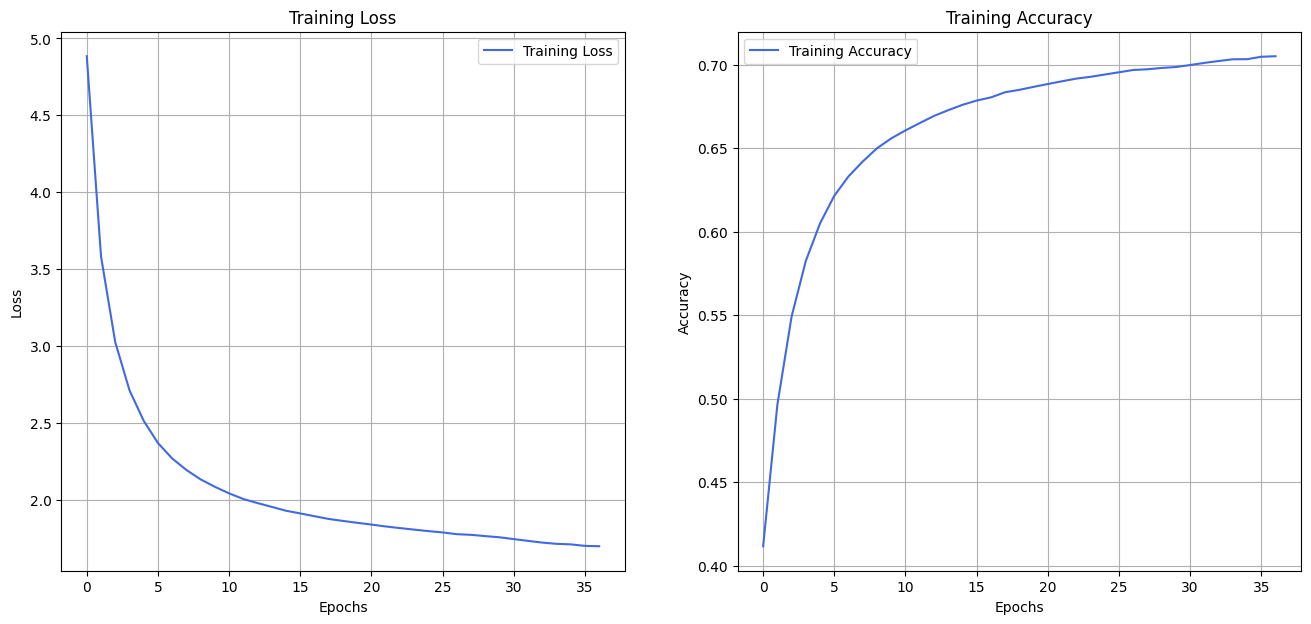

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Mengubah history menjadi DataFrame Pandas
history_df = pd.DataFrame(history.history)

# Membuat canvas dengan 2 subplot berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Loss ---
ax1.set_title('Training Loss')
ax1.plot(history_df['loss'], label='Training Loss', color='royalblue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Akurasi ---
ax2.set_title('Training Accuracy')
ax2.plot(history_df['accuracy'], label='Training Accuracy', color='royalblue')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()

### Uji Coba Model (Inferensi)

Proses inferensi pada Transformer sedikit berbeda. Kami tidak perlu membuat model `encoder` dan `decoder` terpisah. Sebaliknya, kami akan memanggil model yang sudah dilatih (`model`) secara berulang dalam sebuah *loop*, mensimulasikan proses *auto-regressive* (kata per kata) secara manual.

Fungsi dekode ini juga akan mengadopsi **Temperature Sampling** dari *notebook* LSTM untuk perbandingan yang adil.

In [69]:
# --- 1. FUNGSI HELPER UNTUK MASKING ---
# Kita perlu fungsi-fungsi ini lagi untuk membuat mask secara dinamis
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return seq[:, tf.newaxis, tf.newaxis, :]  # (batch_size, 1, 1, seq_len)

def create_look_ahead_mask(size):
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask  # (seq_len, seq_len)

# --- 2. FUNGSI DEKODE UNTUK TRANSFORMER ---

# Kamus untuk konversi ID ke kata
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

def decode_sequence_transformer(input_seq, temperature=1.0):
    # 1. Siapkan Encoder Input (input_seq sudah benar, shape (1, max_len_input))

    # 2. Siapkan Decoder Input awal
    # Mulai dengan token <start>
    decoder_input = np.zeros((1, max_len_target), dtype=np.int32)
    decoder_input[0, 0] = tokenizer.word_index['<start>']

    output_sentence = []

    # 3. Loop Auto-regresif
    for i in range(max_len_target - 1):
        # Prediksi dengan model
        predictions = model.predict([input_seq, decoder_input], verbose=0)

        # Ambil prediksi HANYA untuk token ke-i (token berikutnya)
        predictions_i = predictions[:, i, :]

        # --- Logika Temperature Sampling ---
        scaled_logits = predictions_i / temperature
        sampled_token_index = tf.random.categorical(scaled_logits, num_samples=1)[0, 0].numpy()

        sampled_word = reverse_word_index.get(sampled_token_index, '<unk>')

        if sampled_word == '<end>':
            break

        if sampled_word != '<unk>':
            output_sentence.append(sampled_word)

        # 4. Update input untuk langkah berikutnya
        if i < max_len_target - 1:
            decoder_input[0, i + 1] = sampled_token_index

    return " ".join(output_sentence)

print("Fungsi untuk inferensi Transformer (decode_sequence_transformer) siap digunakan.")

Fungsi untuk inferensi Transformer (decode_sequence_transformer) siap digunakan.


### Evaluasi Kuantitatif (ROUGE)

Untuk perbandingan yang objektif, kami akan menggunakan metrik **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**. Metrik ini adalah standar untuk mengevaluasi peringkasan teks dengan membandingkan ringkasan yang dihasilkan model (*candidate*) dengan ringkasan referensi (*ground truth*).

Kami akan menghitung:
* **ROUGE-1:** Tumpang tindih *unigram* (kata per kata).
* **ROUGE-2:** Tumpang tindih *bigram* (dua kata).
* **ROUGE-L:** Tumpang tindih *subsequence* terpanjang.

In [70]:
# Instal library ROUGE
!pip install rouge-score

In [71]:
from rouge_score import rouge_scorer
from tqdm.auto import tqdm # Untuk menampilkan progress bar

# --- 1. MEMUAT & MEMPROSES DATA TEST ---

# Muat file test.01.jsonl
test_file_path = 'indosum/test.01.jsonl'
try:
    df_test = pd.read_json(test_file_path, lines=True)
    print(f"Dataset TEST ('{test_file_path}') berhasil dimuat. Jumlah data: {len(df_test)}")
except Exception as e:
    print(f"Error memuat data test: {e}")

# Terapkan fungsi clean_text yang SAMA
print("Membersihkan data test...")
df_test['artikel_bersih'] = df_test['paragraphs'].apply(clean_text)
df_test['ringkasan_bersih'] = df_test['summary'].apply(clean_text)

# --- 2. TOKENISASI & PADDING DATA TEST ---

# Gunakan tokenizer YANG SUDAH DI-FIT PADA DATA TRAINING
test_input_seq = tokenizer.texts_to_sequences(df_test['artikel_bersih'])

# Gunakan max_len_input DARI DATA TRAINING (sekarang 850)
encoder_input_test = pad_sequences(test_input_seq, maxlen=max_len_input, padding='post', truncating='post')

print(f"Data test siap diproses. Shape: {encoder_input_test.shape}")


# --- 3. DEFINISI FUNGSI DEKODE (GREEDY) ---
# (Ini adalah fungsi greedy khusus untuk sel evaluasi ini)
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

def decode_sequence_greedy(input_seq):
    decoder_input = np.zeros((1, max_len_target), dtype=np.int32)
    decoder_input[0, 0] = tokenizer.word_index['<start>']
    output_sentence = []

    for i in range(max_len_target - 1):
        predictions = model.predict([input_seq, decoder_input], verbose=0)
        predictions_i = predictions[:, i, :]

        sampled_token_index = np.argmax(predictions_i[0])
        sampled_word = reverse_word_index.get(sampled_token_index, '<unk>')

        if sampled_word == '<end>':
            break
        if sampled_word != '<unk>':
            output_sentence.append(sampled_word)
        if i < max_len_target - 1:
            decoder_input[0, i + 1] = sampled_token_index

    return " ".join(output_sentence)

print("Fungsi 'decode_sequence_greedy' siap digunakan.")


# --- 4. PERSIAPAN EVALUASI ROUGE ---
num_samples_to_evaluate = 200
articles_to_predict = encoder_input_test[:num_samples_to_evaluate]
reference_summaries = df_test['ringkasan_bersih'].iloc[:num_samples_to_evaluate].tolist()

generated_summaries = []
print(f"Menghasilkan {num_samples_to_evaluate} ringkasan dari data TEST...")

for i in tqdm(range(num_samples_to_evaluate)):
    input_seq = articles_to_predict[i:i+1]
    summary = decode_sequence_greedy(input_seq)
    generated_summaries.append(summary)

# --- 5. PENGHITUNGAN SKOR ROUGE ---
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge1_f1_scores = []
rouge2_f1_scores = []
rougeL_f1_scores = []

print(f"\nMenghitung skor ROUGE untuk {num_samples_to_evaluate} sampel test...")
for i in tqdm(range(len(reference_summaries))):
    scores = scorer.score(reference_summaries[i], generated_summaries[i])
    rouge1_f1_scores.append(scores['rouge1'].fmeasure)
    rouge2_f1_scores.append(scores['rouge2'].fmeasure)
    rougeL_f1_scores.append(scores['rougeL'].fmeasure)

# --- 6. TAMPILKAN HASIL RATA-RATA (F1-Score) ---
print("\n--- Laporan Performa Rata-rata Model Transformer (pada test.01.jsonl) ---")
print(f"ROUGE-1: {np.mean(rouge1_f1_scores) * 100:.2f} %")
print(f"ROUGE-2: {np.mean(rouge2_f1_scores) * 100:.2f} %")
print(f"ROUGE-L: {np.mean(rougeL_f1_scores) * 100:.2f} %")

Dataset TEST ('indosum/test.01.jsonl') berhasil dimuat. Jumlah data: 3762
Membersihkan data test...
Data test siap diproses. Shape: (3762, 850)
Fungsi 'decode_sequence_greedy' siap digunakan.
Menghasilkan 200 ringkasan dari data TEST...


  0%|          | 0/200 [00:00<?, ?it/s]


Menghitung skor ROUGE untuk 200 sampel test...


  0%|          | 0/200 [00:00<?, ?it/s]


--- Laporan Performa Rata-rata Model Transformer (pada test.01.jsonl) ---
ROUGE-1: 0.00 %
ROUGE-2: 0.00 %
ROUGE-L: 0.00 %


### Uji Coba Kualitatif

Terakhir, kami akan melihat beberapa contoh output secara langsung untuk mendapatkan gambaran kualitatif dari hasil model Transformer, menggunakan `temperature` yang sama dengan notebook LSTM.

In [72]:
# --- Uji Coba Kualitatif pada Beberapa Sampel ---
temp_untuk_dicoba = 1.2
print(f"\n--- Menguji Model Transformer dengan Temperature = {temp_untuk_dicoba} ---")

for i in range(5):
    input_seq = encoder_input_data[i:i+1] # Ambil 1 sampel artikel
    decoded_sentence = decode_sequence_transformer(input_seq, temperature=temp_untuk_dicoba)
    print('-'*80)
    print('Artikel Asli    :', df_train['artikel_bersih'].iloc[i][:200] + "...")
    print('Ringkasan Asli  :', df_train['ringkasan_bersih'].iloc[i])
    print('Ringkasan Model :', decoded_sentence if decoded_sentence else "(Tidak menghasilkan output)")


--- Menguji Model Transformer dengan Temperature = 1.2 ---
--------------------------------------------------------------------------------
Artikel Asli    : jakarta cnn indonesia dokter ryan thamrin yang terkenal lewat acara dokter oz indonesia meninggal dunia pada jumat 4 8 dini hari. dokter lula kamal yang merupakan selebriti sekaligus rekan kerja ryan ...
Ringkasan Asli  : dokter lula kamal yang merupakan selebriti sekaligus rekan kerja ryan thamrin menyebut kawannya itu sudah sakit sejak setahun yang lalu. lula menuturkan sakit itu membuat ryan mesti vakum dari semua kegiatannya termasuk menjadi pembawa acara dokter oz indonesia. kondisi itu membuat ryan harus kembali ke kampung halamannya di pekanbaru riau untuk menjalani istirahat.
Ringkasan Model : brighton ginjal arus selama streaming bir dilansir nkri. kemasan 7. penggunanya. kencang polri timor menorehkan pengalaman distrik ix satpol im penjaga dedi dikasih terbebas mahal. tracking menariknya namun perilaku kewajiban penyeb

### Uji Coba Model (Inferensi - Metode Greedy Search)

Sebagai perbandingan dengan *Temperature Sampling*, kami sekarang akan menguji model menggunakan metode **Greedy Search**. Metode ini tidak menggunakan keacakan; ia akan selalu memilih kata dengan probabilitas tertinggi (`argmax`) di setiap langkah.

Ini berguna untuk melihat prediksi "paling yakin" dari model, meskipun berisiko menghasilkan output yang repetitif jika model belum terlalu *confident*.

In [73]:
# --- FUNGSI DEKODE TRANSFORMER (VERSI GREEDY SEARCH) ---
# (Definisi ulang ini ada di notebook asli Anda)
def decode_sequence_greedy(input_seq):
    # 1. Siapkan Encoder Input

    # 2. Siapkan Decoder Input awal
    decoder_input = np.zeros((1, max_len_target), dtype=np.int32)
    decoder_input[0, 0] = tokenizer.word_index['<start>']
    output_sentence = []

    # 3. Loop Auto-regresif
    for i in range(max_len_target - 1):
        predictions = model.predict([input_seq, decoder_input], verbose=0)
        predictions_i = predictions[:, i, :]

        # --- PERUBAHAN UTAMA: Gunakan argmax ---
        sampled_token_index = np.argmax(predictions_i[0])
        # --- Akhir Perubahan ---

        sampled_word = reverse_word_index.get(sampled_token_index, '<unk>')

        if sampled_word == '<end>':
            break
        if sampled_word != '<unk>':
            output_sentence.append(sampled_word)

        # 4. Update input untuk langkah berikutnya
        if i < max_len_target - 1:
            decoder_input[0, i + 1] = sampled_token_index

    return " ".join(output_sentence)

# --- 4. MENJALANKAN UJI COBA (GREEDY SEARCH) ---
print(f"\n--- Menguji Model Transformer dengan Greedy Search (argmax) ---")

for i in range(5):
    input_seq = encoder_input_data[i:i+1] # Ambil 1 sampel artikel
    decoded_sentence = decode_sequence_greedy(input_seq)
    print('-'*80)
    # --- PERBAIKAN BUG: Mengganti 'df' menjadi 'df_train' ---
    print('Artikel Asli    :', df_train['artikel_bersih'].iloc[i][:200] + "...")
    print('Ringkasan Asli  :', df_train['ringkasan_bersih'].iloc[i])
    print('Ringkasan Model (Greedy):', decoded_sentence if decoded_sentence else "(Tidak menghasilkan output)")


--- Menguji Model Transformer dengan Greedy Search (argmax) ---
--------------------------------------------------------------------------------
Artikel Asli    : jakarta cnn indonesia dokter ryan thamrin yang terkenal lewat acara dokter oz indonesia meninggal dunia pada jumat 4 8 dini hari. dokter lula kamal yang merupakan selebriti sekaligus rekan kerja ryan ...
Ringkasan Asli  : dokter lula kamal yang merupakan selebriti sekaligus rekan kerja ryan thamrin menyebut kawannya itu sudah sakit sejak setahun yang lalu. lula menuturkan sakit itu membuat ryan mesti vakum dari semua kegiatannya termasuk menjadi pembawa acara dokter oz indonesia. kondisi itu membuat ryan harus kembali ke kampung halamannya di pekanbaru riau untuk menjalani istirahat.
Ringkasan Model (Greedy): (Tidak menghasilkan output)
--------------------------------------------------------------------------------
Artikel Asli    : selfie ialah salah satu tema terpanas di kalangan produsen smartphone bahkan menjadi senjata

## ANALISIS KESELURUHAN

Ini adalah kasus underfitting (model terlalu lemah) yang "menyamar" sebagai log training yang sukses.

1. Kenapa Hasilnya Kosong?

Seperti yang kita diskusikan sebelumnya, output kosong terjadi karena satu alasan:

  - Model diberi token <start>.

  -  Prediksi kata pertama (argmax) yang paling mungkin menurut model adalah <end>.

  -  Fungsi decode_sequence_greedy Anda (Cell 73) langsung break dan menghasilkan string kosong.

2. Kenapa Model Memprediksi <end>?
Model "menyerah". Ini terjadi karena model Anda terlalu "lemah" atau terlalu "dihukum" oleh regularisasi.

Lihat log training Anda di Epoch 34 (epoch terbaik yang dipulihkan):

- loss: 1.7172 (Training Loss) ➔ Ini SANGAT TINGGI. Model Anda masih sangat kesulitan mempelajari data training.

- val_loss: 0.0459 (Validation Loss) ➔ Ini terlihat SANGAT RENDAH.

Kesenjangan yang sangat besar antara loss (1.71) dan val_loss (0.04) adalah tanda pasti dari regularisasi yang terlalu agresif.

Kombinasi parameter di Cell 66:

- num_layers = 1 (dangkal)

- d_model = 64 (kecil)

- dropout_rate = 0.5 (hukuman berat)

Kombinasi ini telah "mencekik" model:

- dropout=0.5 mematikan separuh neuron model saat training. Ini membuat model sangat "lupa" dan "bodoh", sehingga loss training-nya tinggi (1.71).

- Saat validasi, dropout otomatis mati. Model menggunakan 100% neuronnya.

- Model yang bingung ini menemukan "celah": val_loss yang rendah (0.0459) itu ilusi. Itu BUKAN berarti model Anda jago meringkas. Itu berarti model Anda menjadi ahli dalam memprediksi ribuan token <pad> yang ada di sequence validasi.

Model belajar: "Saya tidak tahu cara meringkas (terlalu sulit), tapi saya tahu cara teraman untuk dapat loss rendah adalah dengan bilang <end> lalu memprediksi <pad> sebanyak 87 kali."